##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [8]:
# Exercise 1: Unsupervised Clustering with KMeans using DINOv2 CLS tokens

import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import Subset
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from PIL import Image

# -----------------------------
# 1. Load Oxford-IIIT Pet dataset
# -----------------------------

dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True
)

# Oxford-IIIT Pet has 37 breeds.
# Usually labels 0-11 are cats and 12-36 are dogs.
# So we convert breed label into binary label:
# cat = 0, dog = 1
import random

random.seed(42)

cat_indices = []
dog_indices = []

for i in range(len(dataset)):
    _, label = dataset[i]
    binary_label = cat_dog_label(label)

    if binary_label == 0:
        cat_indices.append(i)
    else:
        dog_indices.append(i)

selected_cat_indices = random.sample(cat_indices, 10)
selected_dog_indices = random.sample(dog_indices, 10)

selected_indices = selected_cat_indices + selected_dog_indices
random.shuffle(selected_indices)

images = []
true_labels = []

for idx in selected_indices:
    img, label = dataset[idx]
    images.append(img.convert("RGB"))
    true_labels.append(cat_dog_label(label))

true_labels = np.array(true_labels)

print("Number of selected images:", len(images))
print("True labels:", true_labels)
print("0 = cat, 1 = dog")

Number of selected images: 20
True labels: [0 0 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 0 1 1]
0 = cat, 1 = dog


In [9]:
# -----------------------------
# 2. Load DINOv2 model
# -----------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_id = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id).to(device)
model.eval()

# -----------------------------
# 3. Extract CLS tokens
# -----------------------------

cls_tokens = []

with torch.no_grad():
    for img in images:
        inputs = processor(images=img, return_tensors="pt").to(device)
        outputs = model(**inputs)

        # last_hidden_state shape:
        # [batch_size, number_of_tokens, hidden_dimension]
        # CLS token is the first token: index 0
        cls_token = outputs.last_hidden_state[:, 0, :]

        cls_tokens.append(cls_token.cpu().numpy().squeeze())

cls_tokens = np.array(cls_tokens)

print("CLS tokens shape:", cls_tokens.shape)

Using device: cuda


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

CLS tokens shape: (20, 384)


In [10]:
# -----------------------------
# 4. Apply KMeans clustering
# -----------------------------

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cls_tokens)

print("Predicted cluster labels:", cluster_labels)
print("Ground-truth labels:", true_labels)

Predicted cluster labels: [0 0 1 1 0 1 1 0 0 0 1 0 1 0 1 1 0 0 0 1]
Ground-truth labels: [0 0 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 0 1 1]


In [11]:
# -----------------------------
# 5. Compare clusters with true cat/dog labels
# -----------------------------

# KMeans cluster numbers are arbitrary.
# Cluster 0 does not necessarily mean cat.
# So we check both mappings and keep the better one.

accuracy_1 = accuracy_score(true_labels, cluster_labels)
accuracy_2 = accuracy_score(true_labels, 1 - cluster_labels)

if accuracy_2 > accuracy_1:
    mapped_clusters = 1 - cluster_labels
    final_accuracy = accuracy_2
else:
    mapped_clusters = cluster_labels
    final_accuracy = accuracy_1

print("Mapped cluster labels:", mapped_clusters)
print("True labels:", true_labels)
print("Clustering accuracy:", final_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, mapped_clusters))

Mapped cluster labels: [0 0 1 1 0 1 1 0 0 0 1 0 1 0 1 1 0 0 0 1]
True labels: [0 0 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 0 1 1]
Clustering accuracy: 0.55

Confusion Matrix:
[[6 4]
 [5 5]]


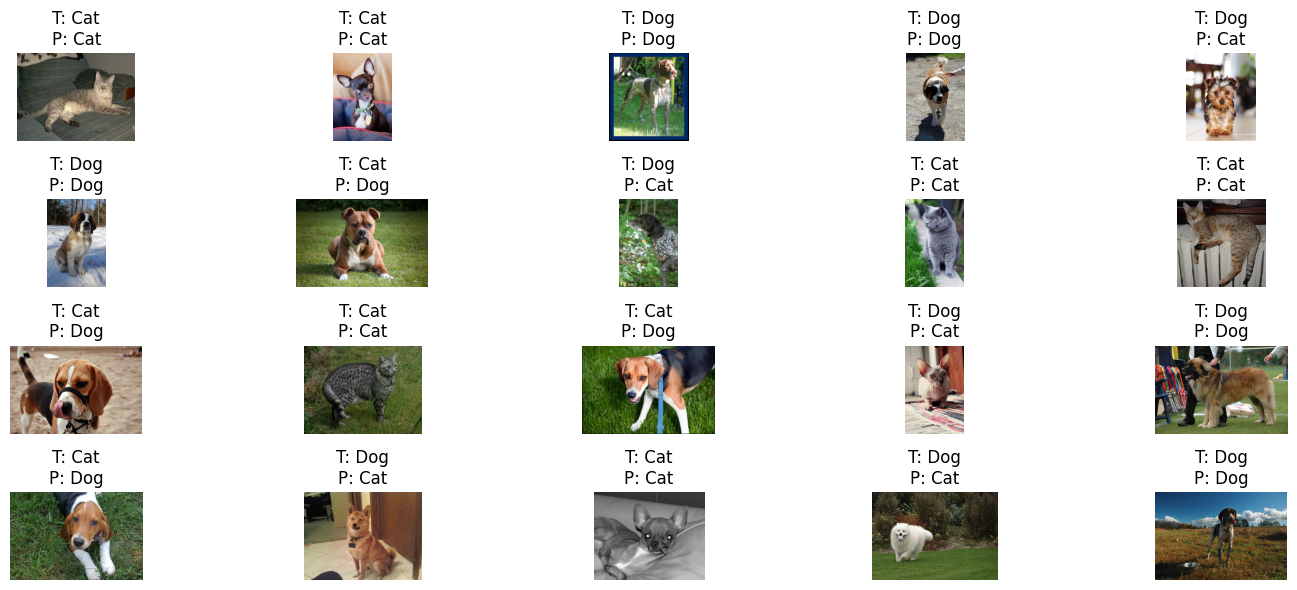

In [12]:
# -----------------------------
# 6. Visualize selected images with true and predicted labels
# -----------------------------

label_names = {
    0: "Cat",
    1: "Dog"
}

plt.figure(figsize=(15, 6))

for i, img in enumerate(images):
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

    true_name = label_names[true_labels[i]]
    pred_name = label_names[mapped_clusters[i]]

    plt.title(f"T: {true_name}\nP: {pred_name}")

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [13]:
# Exercise 2: Image Classification with DINOv2

import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Required model ID from the lab instructions
model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForImageClassification.from_pretrained(model_id).to(device)
model.eval()

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Dinov2ForImageClassification(
  (dinov2): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2Laye

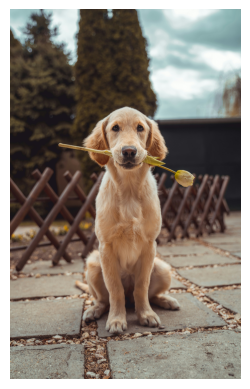

In [14]:
# -----------------------------
# Load an online image
# -----------------------------

image_url = "https://images.unsplash.com/photo-1552053831-71594a27632d"

response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

In [15]:
# -----------------------------
# Run inference
# -----------------------------

inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

predicted_class_id = logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class_id]

print("Predicted class ID:", predicted_class_id)
print("Predicted label:", predicted_label)

Predicted class ID: 207
Predicted label: golden retriever


In [16]:
# -----------------------------
# Show top-5 predictions
# -----------------------------

probabilities = torch.softmax(logits, dim=-1)
top5 = torch.topk(probabilities, k=5)

for rank, (class_id, score) in enumerate(zip(top5.indices[0], top5.values[0]), start=1):
    label = model.config.id2label[class_id.item()]
    confidence = score.item()
    print(f"{rank}. {label} - {confidence:.4f}")

1. golden retriever - 0.9201
2. Labrador retriever - 0.0330
3. tennis ball - 0.0131
4. Brittany spaniel - 0.0118
5. English setter - 0.0045
